# 044 深层卷积与残差网络

从新内核执行全部单元格。先完成lab.md中的纸笔与协议，再读取末端测试结果。本Notebook真实训练24个候选，并重生成11幅图。未使用下载数据或模型。

In [1]:
from pathlib import Path
import sys, os, tempfile, json
roots = [Path.cwd(), Path.cwd()/"units"/"044"]
unit = next((p.resolve() for p in roots if (p/"reference.py").is_file() and (p/"data/manifest.json").is_file()), None)
if unit is None:
    raise RuntimeError("请从044单元目录或完整课程根目录启动Notebook")
sys.path.insert(0, str(unit))
work = Path(tempfile.mkdtemp(prefix="dl044-notebook-"))
os.environ["MPLCONFIGDIR"] = str(work/"mpl")
import numpy as np, torch, matplotlib, nbformat
print("Python", sys.version.split()[0], "解释器", sys.executable)
print("NumPy", np.__version__, "PyTorch", torch.__version__, "Matplotlib", matplotlib.__version__)
print("已创建隔离输出目录；原始outputs不会覆盖。")

Python 3.12.14 解释器 /workspace/scratch/1577d0a62398/course-runtime/bin/python
NumPy 2.3.5 PyTorch 2.7.1+cpu Matplotlib 3.10.8
已创建隔离输出目录；原始outputs不会覆盖。


## 1 原创数据与纸笔网络
图像是带噪声的水平/竖直线段；纸笔网络则使用两条两位置输入，仅为完整展示局部导数。不要把两个问题的损失单位混为一谈。

In [2]:
from reference import hand_ledger
hand = hand_ledger()
for k, r in enumerate(hand["rounds"]):
    print("前向", k, "参数", r["theta"], "平均损失", r["loss"])
    for name, row in zip(["A", "B"], r["rows"]):
        print(name, {key: row[key] for key in ["z", "h", "f", "s", "m", "pred", "weighted_loss", "dz", "gradient", "dx"]})
    print("总梯度", r["gradient"], "同步更新", r["next_theta"])
print("初始损失精确分数", hand["exact_initial_loss"])

前向 0 参数 [0.5, 0.25, 0.4, -0.1, 0.8, 0.1] 平均损失 0.0778
A {'z': [-0.25, 0.75], 'h': [0.0, 0.75], 'f': [-0.1, 0.2], 's': [-1.1, 1.2], 'm': 0.05, 'pred': 0.14, 'weighted_loss': 0.0049, 'dz': [0.0, 0.0112], 'gradient': [0.0112, 0.0112, 0.021, 0.056, 0.0035, 0.07], 'dx': [0.028, 0.0336]}
B {'z': [0.75, 1.25], 'h': [0.75, 1.25], 'f': [0.2, 0.4], 's': [1.2, 2.4], 'm': 1.8, 'pred': 1.54, 'weighted_loss': 0.0729, 'dz': [0.0432, 0.0432], 'gradient': [0.1296, 0.0864, 0.216, 0.216, 0.486, 0.27], 'dx': [0.1296, 0.1296]}
总梯度 [0.1408, 0.0976, 0.237, 0.272, 0.4895, 0.34] 同步更新 [0.48592, 0.24024, 0.3763, -0.1272, 0.75105, 0.066]
前向 1 参数 [0.48592, 0.24024, 0.3763, -0.1272, 0.75105, 0.066] 平均损失 0.03573323081634269
A {'z': [-0.24568, 0.72616], 'h': [0.0, 0.72616], 'f': [-0.1272, 0.146054008], 's': [-1.1272, 1.146054008], 'm': 0.009427004, 'pred': 0.0730801513542, 'weighted_loss': 0.001335177130488195, 'dz': [0.0, 0.005163480194985352], 'gradient': [0.005163480194985352, 0.005163480194985352, 0.00996415832684

## 2 独立参照
检查NumPy滑窗、解析反向、PyTorch自动微分和全元素中心差分。投影覆盖奇数/偶数下采样；输入拒绝使用显式异常，python -O下仍有效。

In [3]:
from test_experiment import run_checks
checks = run_checks()
print(json.dumps(checks, ensure_ascii=False, indent=2))

{
  "numerical_max_errors": {
    "c2_2_h4_s1": 1.4492851363456793e-09,
    "c2_3_h5_s2": 3.9140065494214227e-10,
    "c1_2_h4_s2": 1.3344089722089336e-10,
    "hand_round_0": 5.551115123125783e-17,
    "hand_round_1": 1.1102230246251565e-16,
    "hand_round_2": 2.498001805406602e-16
  },
  "scope": "author numerical checks, not independent QA",
  "optimization_disabled": false
}


## 3 先冻结协议与预算
主比较是同深度的捷径开关。跨深度不等MAC。根据三种子平均最终验证CE选学习率，不挑中间最佳epoch。下面先打印固定候选，随后完整训练。

In [4]:
from experiment import budget, SEEDS, LRS, DEPTHS, EPOCHS, BATCH
print("种子", SEEDS, "学习率", LRS, "块数", DEPTHS, "epochs", EPOCHS, "batch", BATCH)
for b in DEPTHS:
    for skip in [False, True]:
        print("Residual" if skip else "Plain", b, budget(b, skip))

种子 (11, 29, 47) 学习率 (0.03, 1.0) 块数 (2, 6) epochs 18 batch 32
Plain 2 {'parameters': 2474, 'conv_layers': 5, 'linear_layers': 1, 'forward_conv_linear_macs_per_example': 342160, 'shortcut_adds_per_example': 0, 'updates': 144, 'training_examples_seen': 4608, 'note': 'MAC excludes BN, ReLU, pooling, additions, backward and evaluation; one MAC is one multiply-accumulate.'}
Residual 2 {'parameters': 2474, 'conv_layers': 5, 'linear_layers': 1, 'forward_conv_linear_macs_per_example': 342160, 'shortcut_adds_per_example': 2304, 'updates': 144, 'training_examples_seen': 4608, 'note': 'MAC excludes BN, ReLU, pooling, additions, backward and evaluation; one MAC is one multiply-accumulate.'}
Plain 6 {'parameters': 7210, 'conv_layers': 13, 'linear_layers': 1, 'forward_conv_linear_macs_per_example': 1005712, 'shortcut_adds_per_example': 0, 'updates': 144, 'training_examples_seen': 4608, 'note': 'MAC excludes BN, ReLU, pooling, additions, backward and evaluation; one MAC is one multiply-accumulate.'}
R

## 4 全部真实训练
这一步调用PyTorch优化器执行3456次更新，不是读取预制轨迹。每次打印终点；所有小批/epoch轨迹会保留。测试集只在选择冻结后读取。

In [5]:
from experiment import run
results = run(work/"outputs")
print("保存候选", len(results["runs"]), "正式测试", len(results["tests"]))
print(json.dumps(results["selections"], ensure_ascii=False, indent=2))

plain_b2_lr0.03_s11 completed {'epoch': 18, 'train': {'loss': 0.0149457398802042, 'accuracy': 1.0}, 'validation': {'loss': 0.03149261325597763, 'accuracy': 1.0}}


residual_b2_lr0.03_s11 completed {'epoch': 18, 'train': {'loss': 0.010566809214651585, 'accuracy': 1.0}, 'validation': {'loss': 0.03822511434555054, 'accuracy': 0.9765625}}


plain_b2_lr0.03_s29 completed {'epoch': 18, 'train': {'loss': 0.012788969092071056, 'accuracy': 1.0}, 'validation': {'loss': 0.0405343659222126, 'accuracy': 0.984375}}


residual_b2_lr0.03_s29 completed {'epoch': 18, 'train': {'loss': 0.0074861133471131325, 'accuracy': 1.0}, 'validation': {'loss': 0.0351351723074913, 'accuracy': 0.984375}}


plain_b2_lr0.03_s47 completed {'epoch': 18, 'train': {'loss': 0.03123706951737404, 'accuracy': 0.99609375}, 'validation': {'loss': 0.07444107532501221, 'accuracy': 0.9765625}}


...

plain_b6_lr1_s29 completed {'epoch': 18, 'train': {'loss': 0.00017505549476481974, 'accuracy': 1.0}, 'validation': {'loss': 0.05713966116309166, 'accuracy': 0.9921875}}


residual_b6_lr1_s29 completed {'epoch': 18, 'train': {'loss': 0.007513199932873249, 'accuracy': 1.0}, 'validation': {'loss': 0.022670799866318703, 'accuracy': 0.9921875}}


plain_b6_lr1_s47 completed {'epoch': 18, 'train': {'loss': 0.017930520698428154, 'accuracy': 0.9921875}, 'validation': {'loss': 0.05797505006194115, 'accuracy': 0.9765625}}


residual_b6_lr1_s47 completed {'epoch': 18, 'train': {'loss': 0.01423174049705267, 'accuracy': 0.9921875}, 'validation': {'loss': 0.05467405915260315, 'accuracy': 0.984375}}


保存候选 24 正式测试 12
[
  {
    "blocks": 2,
    "skip": false,
    "chosen_lr": 0.03,
    "candidates": [
      {
        "lr": 0.03,
        "mean_validation_loss": 0.04882268483440081
      },
      {
        "lr": 1.0,
        "mean_validation_loss": 0.05052821896970272
      }
    ]
  },
  {
    "blocks": 2,
    "skip": true,
    "chosen_lr": 0.03,
    "candidates": [
      {
        "lr": 0.03,
        "mean_validation_loss": 0.05104491114616394
      },
      {
        "lr": 1.0,
        "mean_validation_loss": 0.061254117637872696
      }
    ]
  },
  {
    "blocks": 6,
    "skip": false,
    "chosen_lr": 0.03,
    "candidates": [
      {
        "lr": 0.03,
        "mean_validation_loss": 0.04752102339019378
      },
      {
        "lr": 1.0,
        "mean_validation_loss": 0.05133302385608355
      }
    ]
  },
  {
    "blocks": 6,
    "skip": true,
    "chosen_lr": 0.03,
    "candidates": [
      {
        "lr": 0.03,
        "mean_validation_loss": 0.02984936845799287
      },
 

## 5 正式结果与失败诊断
BN诊断在复制的峰值模型上进行，只用训练输入重估统计，保持可学习权重不变。它不替换选择成绩。

In [6]:
for result in results["tests"]:
    print(result["id"], "准确率", result["accuracy"], "CE", result["loss"], "错误索引", result["mistakes"])
for result in results["runs"]:
    if result["id"] == "plain_b6_lr1_s47":
        print("BN峰值诊断", json.dumps(result["bn_peak_diagnostic"], ensure_ascii=False, indent=2))
if not all(r["status"] == "completed" for r in results["runs"]):
    print("存在未完成候选，必须保留并解释；不要隐藏。")

plain_b2_lr0.03_s11 准确率 0.99609375 CE 0.022916557267308235 错误索引 [205, 337]
plain_b2_lr0.03_s29 准确率 0.994140625 CE 0.026611603796482086 错误索引 [205, 337, 511]
plain_b2_lr0.03_s47 准确率 0.986328125 CE 0.056556083261966705 错误索引 [205, 221, 229, 297, 300, 325, 472]
residual_b2_lr0.03_s11 准确率 0.998046875 CE 0.018737386912107468 错误索引 [337]
residual_b2_lr0.03_s29 准确率 0.994140625 CE 0.021759584546089172 错误索引 [205, 242, 337]
residual_b2_lr0.03_s47 准确率 0.994140625 CE 0.026116682216525078 错误索引 [10, 89, 124]
plain_b6_lr0.03_s11 准确率 0.9921875 CE 0.027861865237355232 错误索引 [29, 89, 237, 271]
plain_b6_lr0.03_s29 准确率 0.9921875 CE 0.02473658323287964 错误索引 [205, 268, 326, 472]
plain_b6_lr0.03_s47 准确率 0.984375 CE 0.04715477675199509 错误索引 [93, 205, 229, 307, 325, 326, 472, 494]
residual_b6_lr0.03_s11 准确率 0.9921875 CE 0.018524162471294403 错误索引 [2, 10, 29, 271]
residual_b6_lr0.03_s29 准确率 0.99609375 CE 0.014235331676900387 错误索引 [205, 472]
residual_b6_lr0.03_s47 准确率 0.990234375 CE 0.02514207921922207 错误索引 [93, 205,

## 6 重新绘制全部图
以下11幅均由本次运行结果生成。图7保留所有种子；图8是固定训练探针的eval梯度；图9隔离BN状态；图11完整显示指定模型的全部错误。

实际生成图数 11
01_plain_residual.png


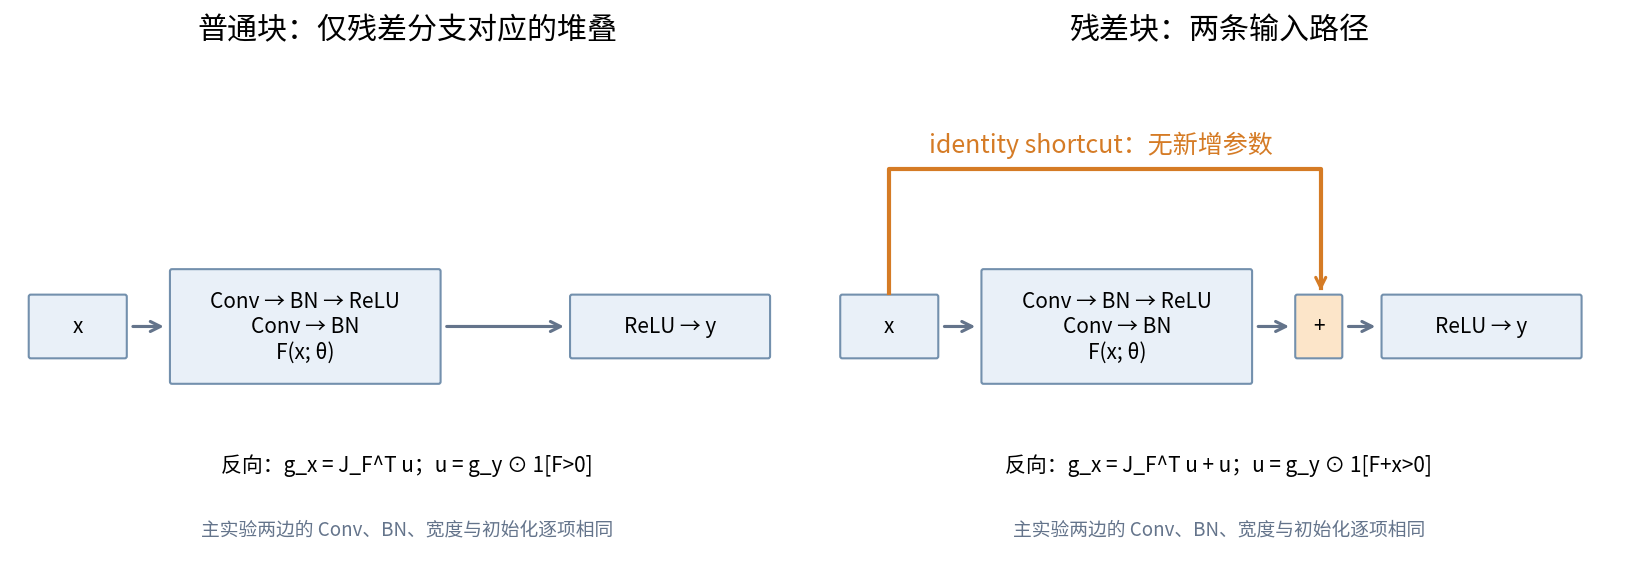

02_projection_shapes.png


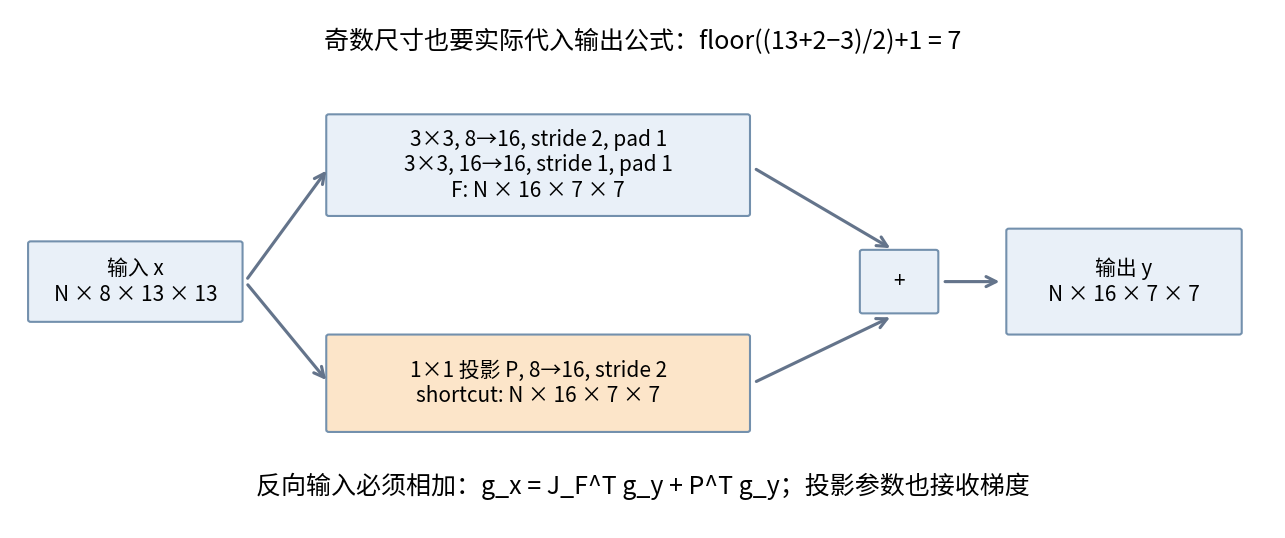

03_hand_forward.png


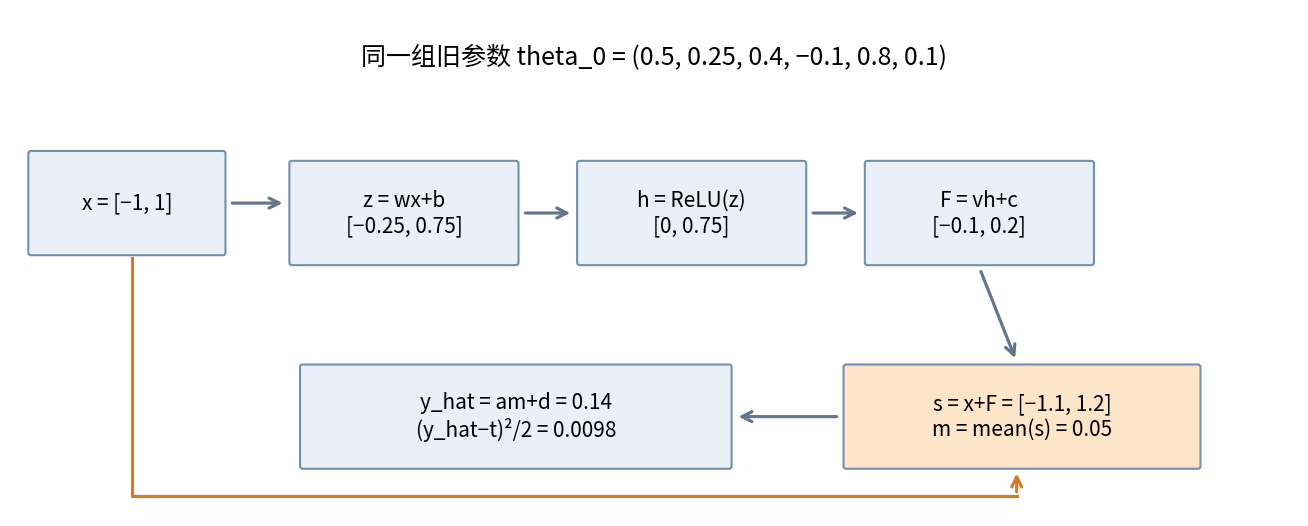

04_parameter_ledger.png


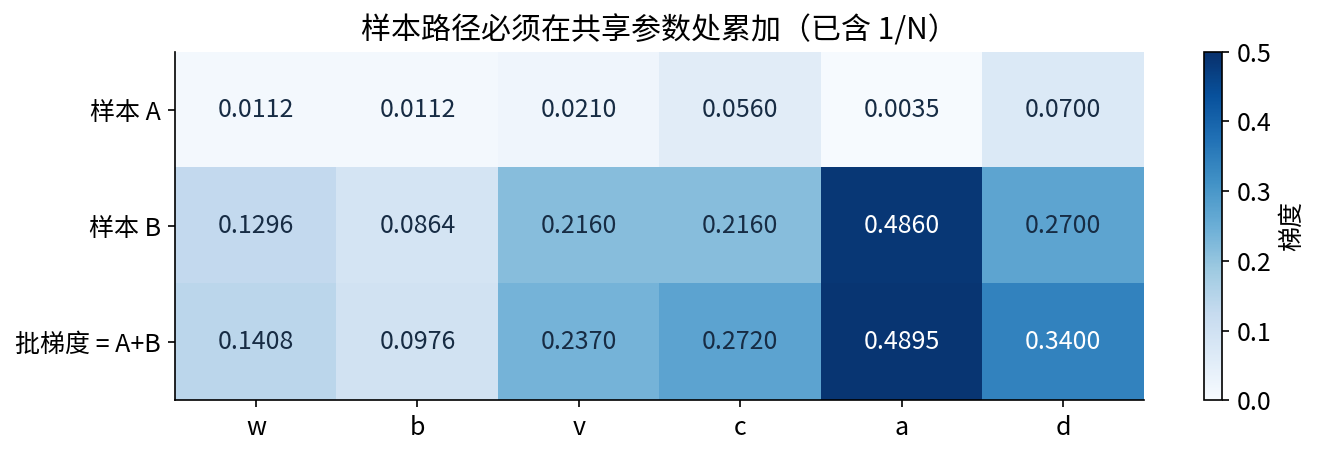

05_hand_updates.png


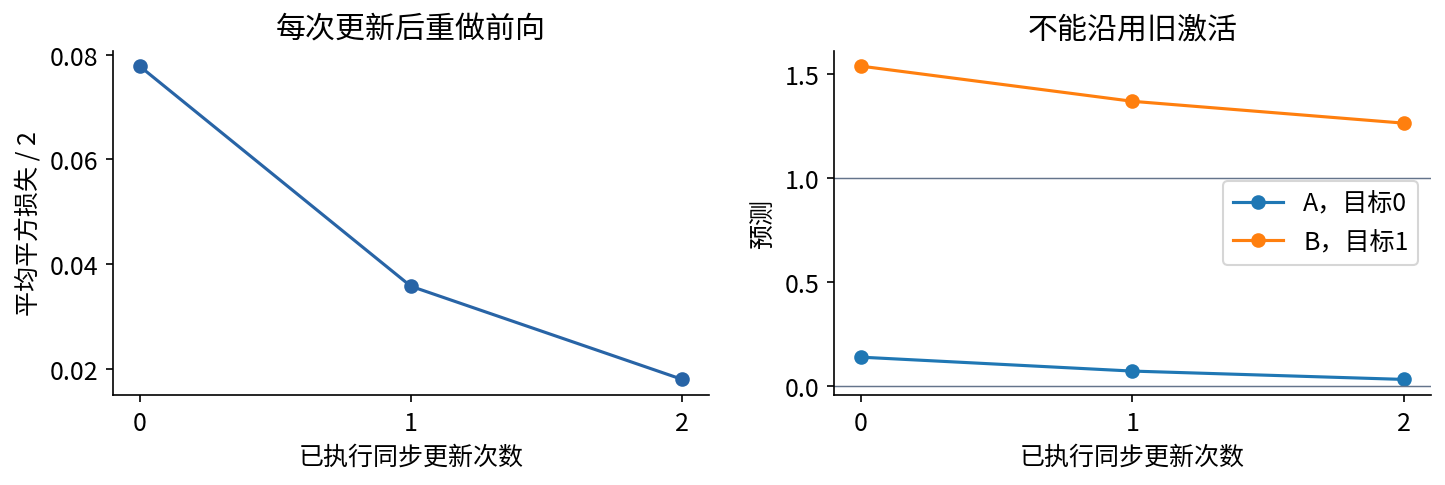

06_data.png


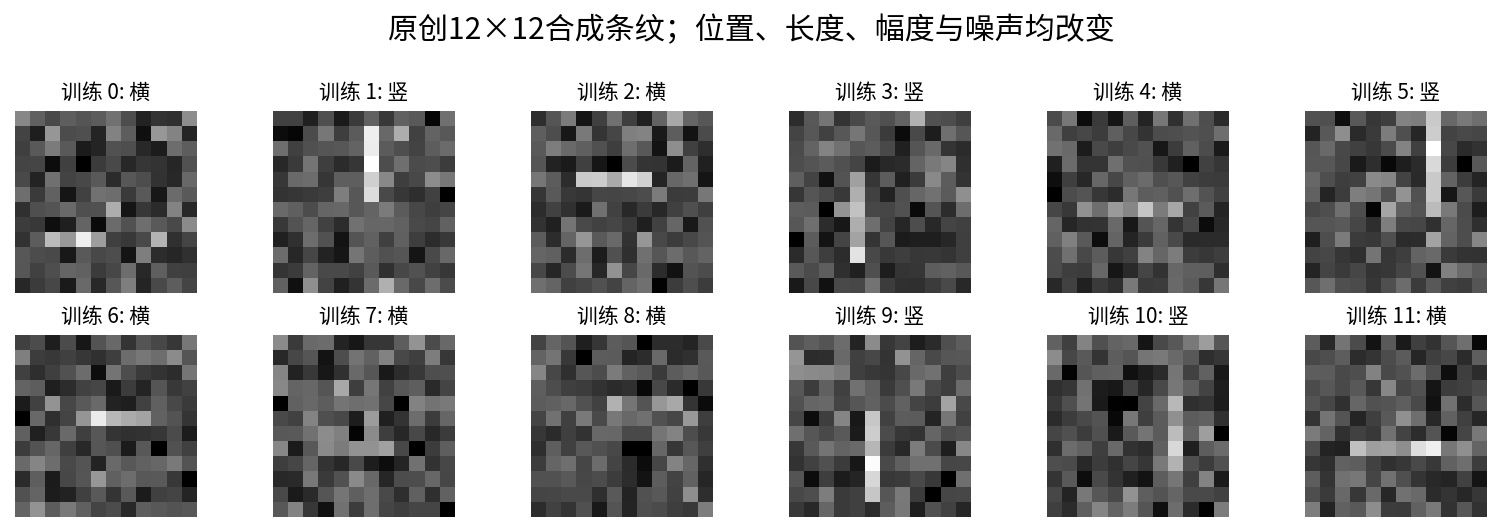

07_all_learning_curves.png


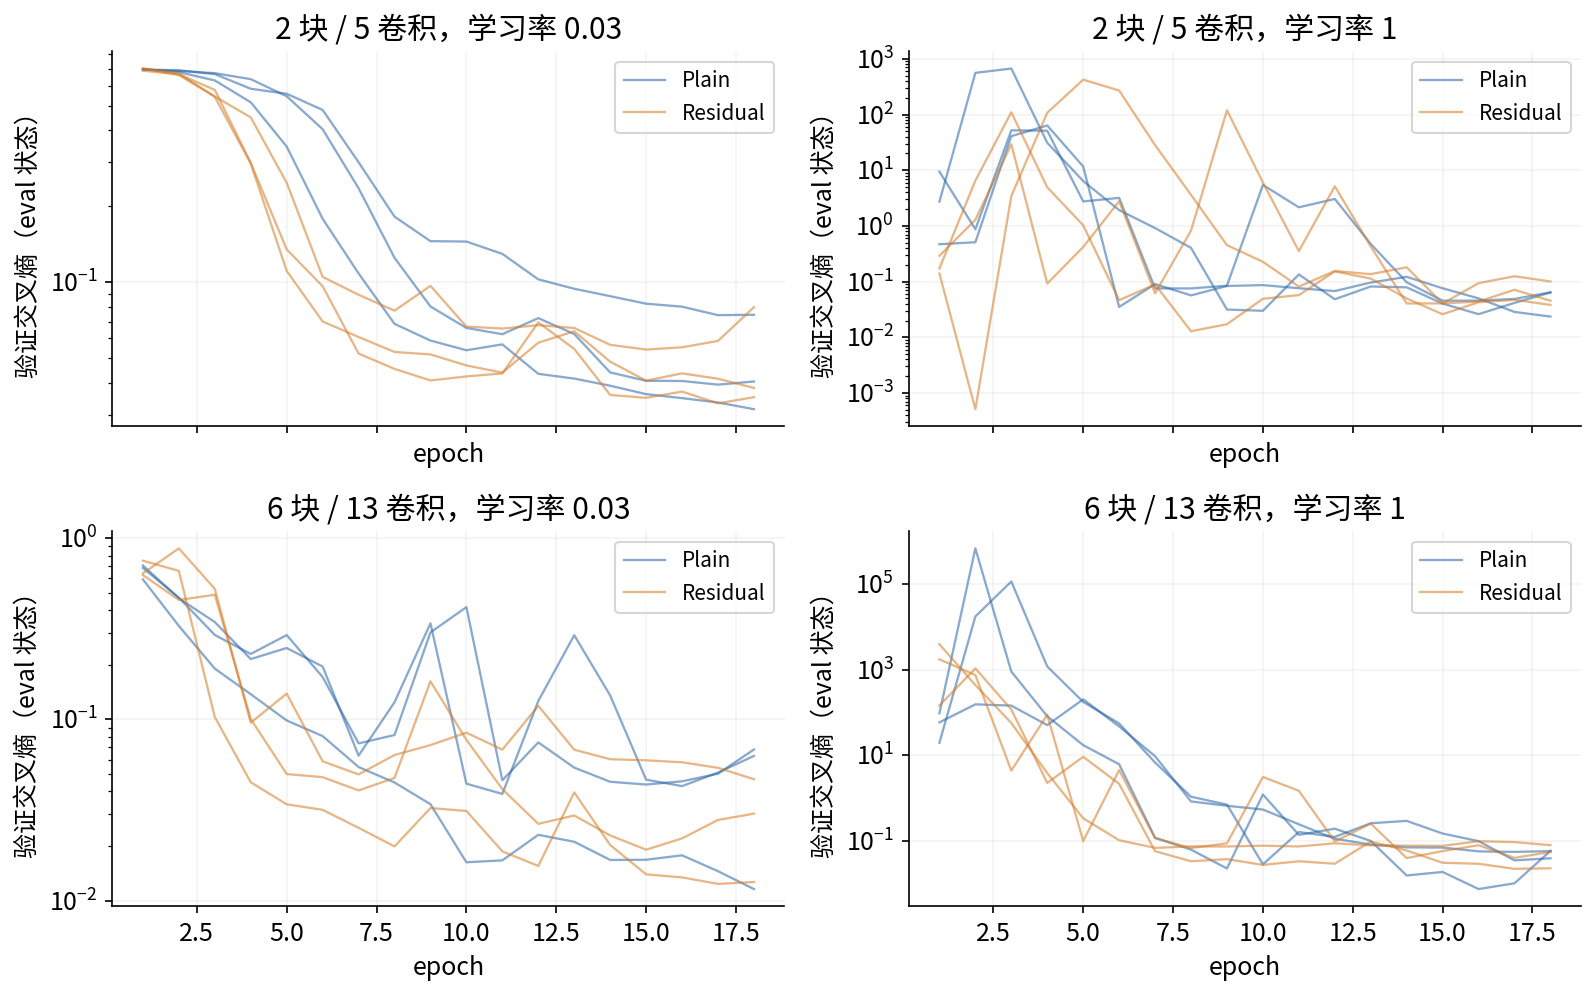

08_gradient_profiles.png


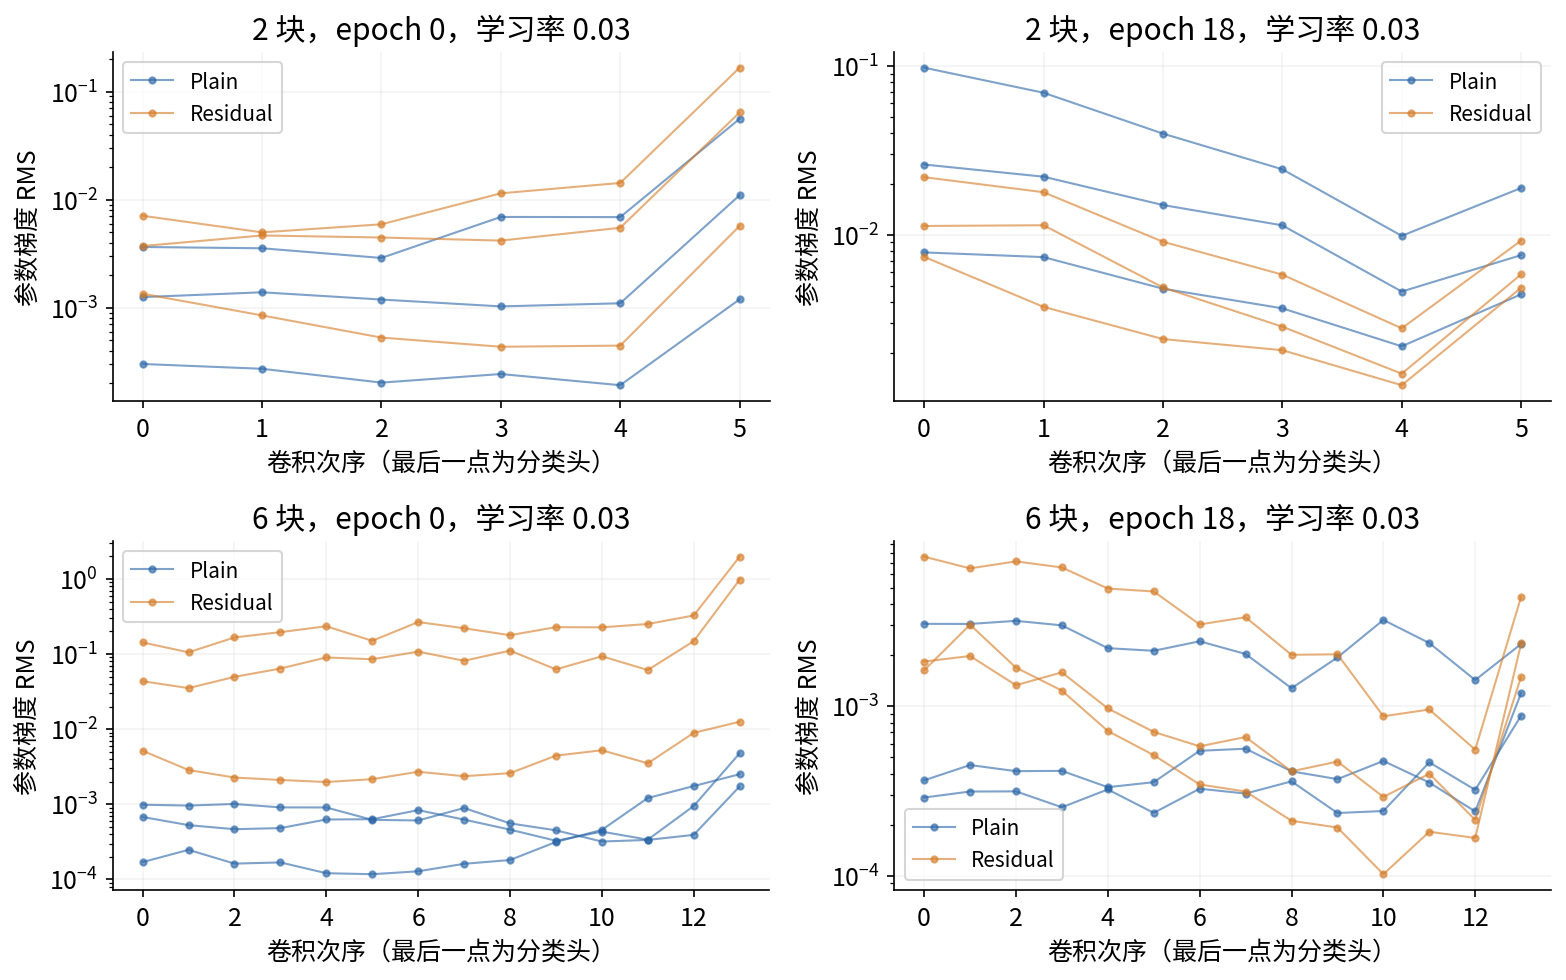

09_bn_instability.png


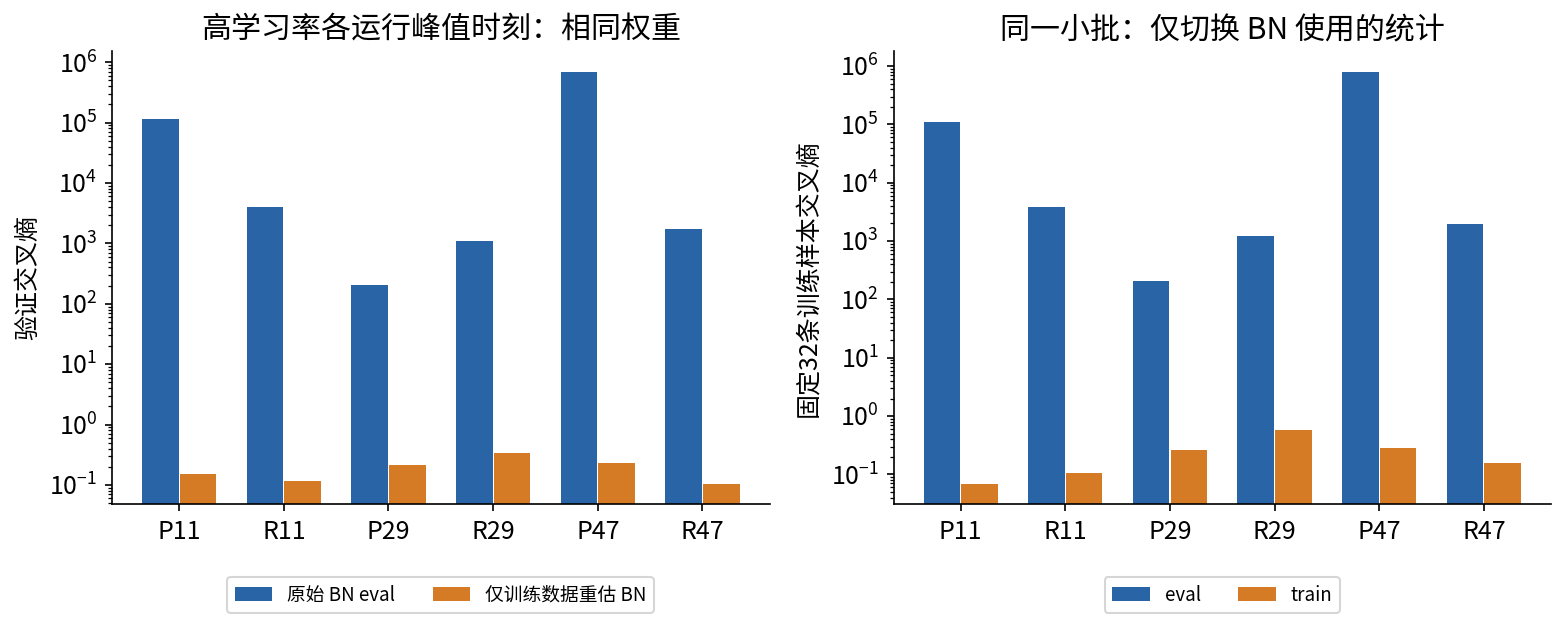

10_paired_test.png


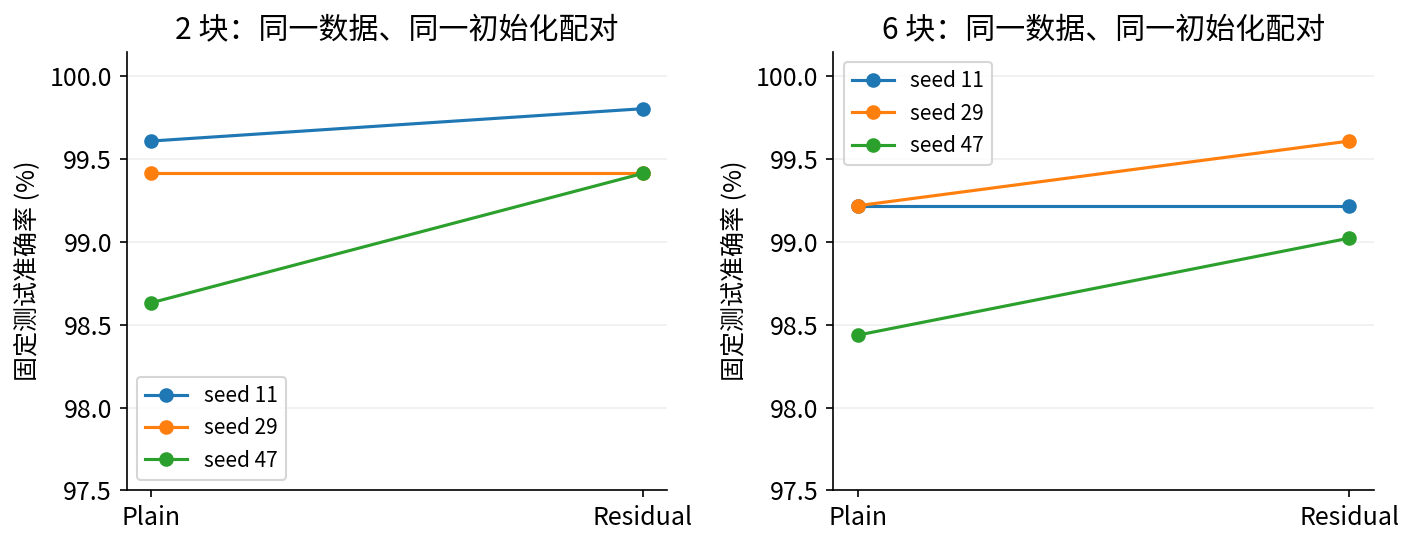

11_all_errors.png


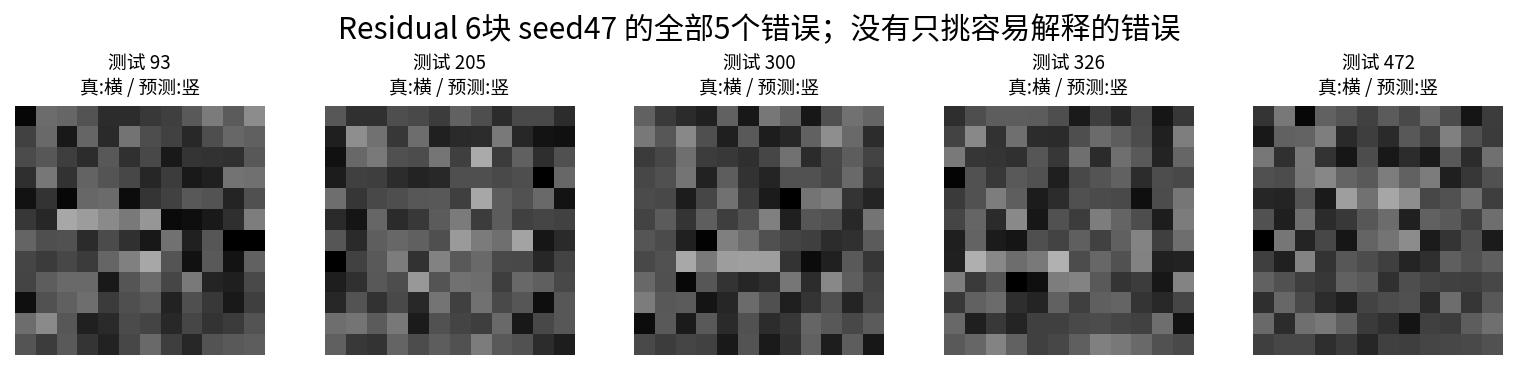

In [7]:
from make_figures import main as make_figures
from IPython.display import display, Image
make_figures(work/"outputs/results.json", work/"figures")
figure_files = sorted((work/"figures").glob("*.png"))
print("实际生成图数", len(figure_files))
for file in figure_files:
    print(file.name)
    display(Image(filename=str(file), width=920))

## 7 复现核对与审慎结论
忽略墙钟计时后，与包内原始结果逐字段比较。在相同CPU/库版本下应一致；跨平台不保证逐位一致。真正的研究结论要同时保留浅层验证CE略差、深层普通网成功拟合、BN失稳与有限合成任务的边界。

In [8]:
original = json.loads((unit/"outputs/results.json").read_text())
def scientific_part(obj):
    obj = json.loads(json.dumps(obj))
    for run_ in obj["runs"]:
        run_.pop("wall_seconds", None)
    obj.pop("environment", None)
    return obj
same = scientific_part(results) == scientific_part(original)
print("剔除运行时间和环境元数据后与原版完全一致:", same)
if not same:
    print("请检查版本、数据、改动与数值差异，不能自行宣称复现通过。")
print("四个验证选择", [(s["blocks"], s["skip"], s["chosen_lr"]) for s in results["selections"]])

剔除运行时间和环境元数据后与原版完全一致: True
四个验证选择 [(2, False, 0.03), (2, True, 0.03), (6, False, 0.03), (6, True, 0.03)]
